# Load PV data (PV)

In [34]:
import pandas as pd

In [35]:
pv = pd.read_csv('Wülknitz Energy Meter Janitza UMG 104 2024.csv', 
                 sep=';', 
                 decimal='.', 
                 thousands = ',',
                 index_col=0)
pv.index = pd.to_datetime(pv.index, format='%d.%m.%Y %H:%M:%S')

In [36]:
pv.tail()

,Wülknitz Janitza UMG 104 AC Power L1234 [W] [avg],Unnamed: 2
Date,,
2024-12-31 23:00:00,38367.77333,NaN
2024-12-31 23:15:00,39060.85333,NaN
2024-12-31 23:30:00,38586.87333,NaN
2024-12-31 23:45:00,38266.32667,NaN
2025-01-01 00:00:00,38641.57143,NaN


In [37]:
pv.rename(columns={'Wülknitz Janitza UMG 104 AC Power L1234 [W] [avg]':'PV'}, inplace=True)
pv.drop(columns=['Unnamed: 2'], inplace=True)

In [38]:
pv.tail()

,PV
Date,
2024-12-31 23:00:00,38367.77333
2024-12-31 23:15:00,39060.85333
2024-12-31 23:30:00,38586.87333
2024-12-31 23:45:00,38266.32667
2025-01-01 00:00:00,38641.57143


In [39]:
pv.fillna(0)

,PV
Date,
2024-01-01 00:15:00,0.00000
2024-01-01 00:30:00,0.00000
2024-01-01 00:45:00,0.00000
2024-01-01 01:00:00,37929.20000
2024-01-01 01:15:00,37713.66667
...,...
2024-12-31 23:00:00,38367.77333
2024-12-31 23:15:00,39060.85333
2024-12-31 23:30:00,38586.87333


In [40]:
pv.PV = pv.PV * -1 / 1000000

<Axes: xlabel='Date'>

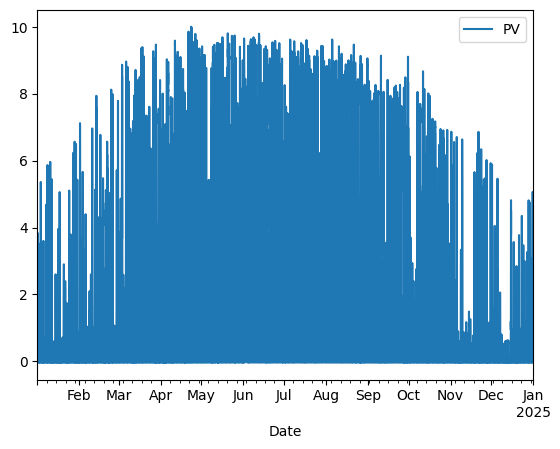

In [41]:
pv.plot()

In [42]:
pv.to_csv('2024_pv.csv')